In [1]:
!git clone https://github.com/hossambalaha/hmbd-v1.git

fatal: destination path 'hmbd-v1' already exists and is not an empty directory.


In [2]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import cv2
import os

In [3]:
data_dir = '/content/hmbd-v1/Dataset'
images = []
labels = []
digits = ['Zero', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Nine']

for label, digit in enumerate(digits):
    digit_dir = os.path.join(data_dir, digit)
    if os.path.isdir(digit_dir):
        for img_name in os.listdir(digit_dir):
            img_path = os.path.join(digit_dir, img_name)
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            image = cv2.resize(image, (150, 150))
            images.append(image)
            labels.append(label)

images = np.array(images).reshape(-1, 150, 150, 1) / 255.0
labels = to_categorical(np.array(labels), 10)

images_rgb = np.array([cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB) for img in images])
images_rgb = preprocess_input(images_rgb)

X_train, X_test, y_train, y_test = train_test_split(images_rgb, labels, test_size=0.2, random_state=42)

In [19]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = datagen.flow(X_train, y_train, batch_size=20)

In [28]:
xception_model = Xception(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

input_layer = Input(shape=(150, 150, 3))
x = xception_model(input_layer, training=True)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
out_layer = Dense(10, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=out_layer)

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xception (Functional)                │ (None, 5, 5, 2048)          │      20,861,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 51200)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │       6,553,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 27,416,498 (104.59 MB)

 Trainable params: 27,361,970 (104.38 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [29]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'digit_recognition_model_xception.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.6126 - loss: 1.1873
Epoch 1: val_accuracy improved from -inf to 0.91034, saving model to digit_recognition_model_xception.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 122s 380ms/step - accuracy: 0.6135 - loss: 1.1847 - val_accuracy: 0.9103 - val_loss: 0.3179
Epoch 2/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9160 - loss: 0.2727
Epoch 2: val_accuracy improved from 0.91034 to 0.93354, saving model to digit_recognition_model_xception.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 48s 246ms/step - accuracy: 0.9160 - loss: 0.2727 - val_accuracy: 0.9335 - val_loss: 0.1952
Epoch 3/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9311 - loss: 0.2445
Epoch 3: val_accuracy improved from 0.93354 to 0.97257, saving model to digit_recognition_model_xception.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 53s 278ms/step - accuracy: 0.9311 - loss: 0.2443 - val_accuracy: 0.9726 - val_loss: 0.1025
Epoch 4/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 16

In [30]:
train_loss = history.history['loss'][-1]
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Training Loss: {train_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")

train_accuracy = history.history['accuracy'][-1]
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Training Loss: 0.1061
Test Loss: 0.0818
Training Accuracy: 96.49%
Test Accuracy: 97.26%


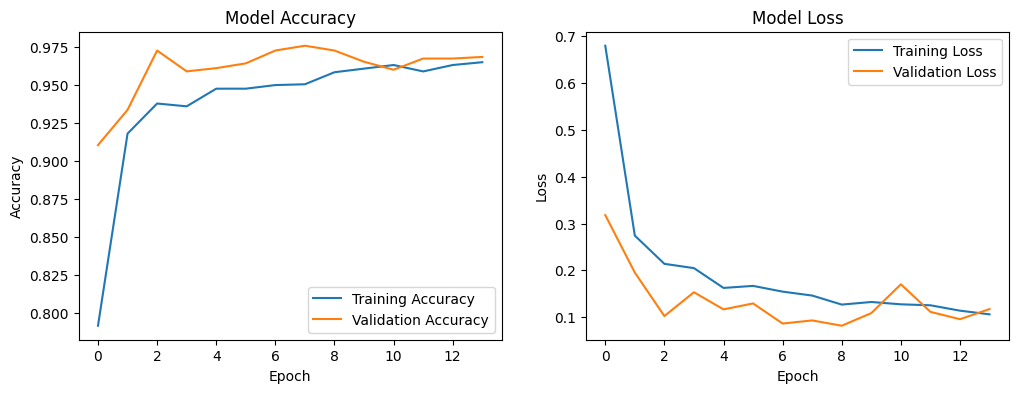

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step


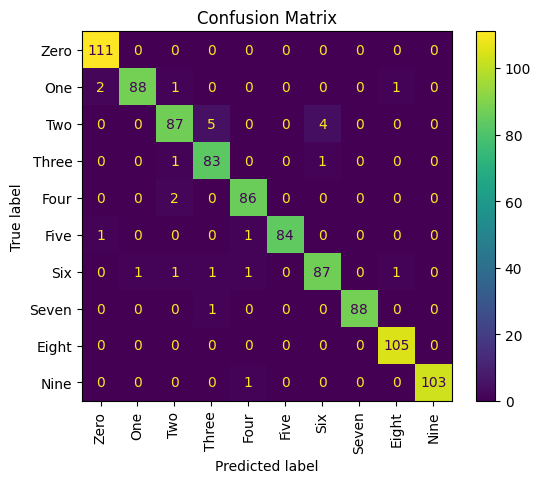

In [32]:
!pip install scikit-learn
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=digits)
disp.plot(cmap='viridis', xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted Digit: 2


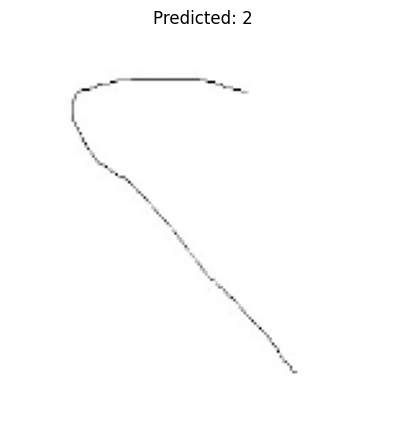

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

test_image_path = '/content/two.jpg'

image = cv2.imread(test_image_path, cv2.IMREAD_GRAYSCALE)

if image is not None:
    image = cv2.resize(image, (150, 150))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    image_rgb = image_rgb / 255.0
    image_rgb = np.expand_dims(image_rgb, axis=0)

    prediction = model.predict(image_rgb)

    predicted_class = np.argmax(prediction, axis=1)[0]

    print(f"Predicted Digit: {predicted_class}")

    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap='gray')
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')
    plt.show()
else:
    print("Error: Unable to load the image. Please check the file path.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicted Digit: 6


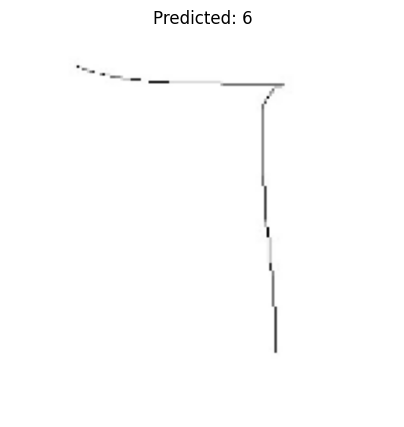

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

test_image_path = '/content/six.jpg'

image = cv2.imread(test_image_path, cv2.IMREAD_GRAYSCALE)

if image is not None:
    image = cv2.resize(image, (150, 150))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    image_rgb = image_rgb / 255.0
    image_rgb = np.expand_dims(image_rgb, axis=0)

    prediction = model.predict(image_rgb)

    predicted_class = np.argmax(prediction, axis=1)[0]

    print(f"Predicted Digit: {predicted_class}")

    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap='gray')
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')
    plt.show()
else:
    print("Error: Unable to load the image. Please check the file path.")
